# Single User Resource Allocation Model

This notebook is the reviewer-facing walkthrough of the single-user workflow after the candidate-evaluation logic has been moved into the shared candidate-evaluation layer.

I use one fixed user case and one preset, ask the shared search entry point to evaluate the candidate configurations, and then interpret the returned rows in resource terms. The aim is practical: to show how the search layer can be used to estimate the time-frequency-layer resources needed to satisfy one user's average-rate requirement, and how that requirement maps to average PA DC power.

The notebook follows one simple story. I first define the inputs, then build the shared search inputs, evaluate the candidate table, interpret the best feasible row as a resource block, and finally place that row inside the broader feasible operating space.


## 1. Explicit inputs and single-user case

I start by loading the preset configuration used by this notebook. That preset provides the link constants, PHY constants, scheduler sweep, MCS table, and PA dataset.

I then define one concrete user case with a fixed distance and one required average downlink rate. There is no multi-distance sweep here. The purpose is to keep the notebook focused on one clear reviewer example: one user, one deployment point, and one target rate.


In [1]:
import os
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from IPython.display import display

DOC_IMG_DIR = Path.cwd() / "img"
DOC_IMG_DIR.mkdir(parents=True, exist_ok=True)

def export_doc_figure(fig, filename):
    output_path = DOC_IMG_DIR / filename
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    print(f"Saved figure to {output_path}")
    return output_path

sys.path.insert(0, str((Path.cwd() / "src").resolve()))

from single_user_search import search_candidates
from single_user_study import (
    build_single_user_scenario,
    preview_single_user_candidates,
    summarize_single_user_scenario,
)


In [2]:
user_case = {
    "distance_m": 100.0,
    "rate_target_bps": 80e6,
}

scenario = build_single_user_scenario(
    distance_m=float(user_case["distance_m"]),
    required_rate_bps=float(user_case["rate_target_bps"]),
)
search_result = search_candidates(
    distance_m=float(user_case["distance_m"]),
    required_rate_bps=float(user_case["rate_target_bps"]),
)
search_views = summarize_single_user_scenario(scenario)
deployment_summary = search_views["deployment_summary"]
pa_characteristics = search_views["pa_characteristics"]
rrc_catalog = search_views["rrc_catalog"]
search_space_detail = search_views["search_space_detail"]
search_space_summary = search_views["search_space_summary"]

scheduler_sweep_table = search_space_detail.copy()
user_case_table = pd.DataFrame([user_case])

display(scheduler_sweep_table)
display(user_case_table)


,bandwidth_space_hz,layers_space,mcs_min,mcs_max,prb_step,mcs_entry_count
0,"(50000000.0, 100000000.0)","(1, 2, 4)",0,28,5,29


,distance_m,rate_target_bps
0,100.0,80000000.0


## 2. Shared engine and notebook boundary

At this point I build one prepared study scenario, ask the public `single_user_search.search_candidates(...)`
engine for the feasible candidate space, and use the study helper only to summarize the underlying deployment
and search-space shape.

This is the notebook boundary. The notebook does not build deployments, choose presets, or implement the
candidate loops itself. Instead, it asks the shared engine for one canonical feasible candidate space and then
explains the returned result tables in a reviewer-friendly way.


In [3]:
display(pa_characteristics)


,pa_id,pa_name,source_csv,n_curve_points,p_max_w,p_idle_w,eta_max,g_pa_eff_linear,g_pa_eff_db,kappa_distortion,backoff_db
0,0,Bae et al. NR,PA models\3.5Ghz_pas\4W_8W_NR_combined_NR_carr...,64,7.928899,5.239623,0.418165,1817.545759,32.594854,0.08,6.0
1,1,QPA9942,PA models\3.5Ghz_pas\4W_8W_NR_combined_NR_carr...,64,1.784671,0.641172,0.352236,935.848316,29.712055,0.08,6.0


## 3. Search result for the chosen user

The next step is to inspect the strict search result for the chosen distance/rate pair.

I request the search-space summary from the returned result object before looking at candidate rows. This gives the reviewer a compact sense of how large the discrete configuration space is for this single-user case.


In [4]:
display(search_space_summary)


,pa_count,scenario_count,raw_configs_per_pa_per_scenario,raw_configs_per_scenario,raw_total_configs,n_slots_on_values,layers_values,n_active_tx_values,mcs_values,prb_step
0,2,1,389760,779520,779520,20,3,4,29,5


## 4. Candidate enumeration and evaluation

Here I request three complementary views from the shared search result.

First, I show a short candidate preview so the reviewer can see the structure of the discrete scheduler tuples. Second, I request the full evaluated candidate table, including infeasible rows. Third, I filter the feasible subset that satisfies the required average-rate constraint.

The displayed tables are therefore summaries of search-layer output, not alternative models reimplemented in the notebook. The public columns are kept intentionally compact so the main rate, power, and resource decisions remain easy to follow.


In [5]:
PUBLIC_CONFIG_COLUMNS = [
    "distance_m",
    "path_loss_db",
    "pa_id",
    "pa_name",
    "rate_ach_bps",
    "p_dc_avg_total_w",
    "layers",
    "mcs",
    "n_prb",
    "n_slots_on",
    "alpha_f",
    "alpha_t",
    "bandwidth_hz",
    "n_active_tx",
    "p_out_total_w",
    "ps_total_w",
    "gamma_req_lin",
]

candidate_preview = preview_single_user_candidates(scenario).copy()
candidate_table = search_result.copy().reset_index(drop=True)
feasible_table = candidate_table.copy()

feasibility_summary = pd.DataFrame(
    [
        {
            "candidate_space": "returned_feasible_space",
            "count": int(len(candidate_table)),
        }
    ]
)

best_feasible_row = (
    feasible_table.sort_values(["p_dc_avg_total_w", "bandwidth_hz", "n_prb", "n_slots_on"])
    .reset_index(drop=True)
    .iloc[0]
    if not feasible_table.empty
    else None
)
best_feasible = (
    pd.DataFrame([best_feasible_row[PUBLIC_CONFIG_COLUMNS]])
    if best_feasible_row is not None
    else pd.DataFrame(columns=PUBLIC_CONFIG_COLUMNS)
)

display(candidate_preview)
display(feasibility_summary)
display(best_feasible)


,pa_id,bwp_idx,n_prb,n_slots_on,layers,n_active_tx,mcs
0,0,0,1,1,1,1,0
1,0,0,1,1,1,1,1
2,0,0,1,1,1,1,2
3,0,0,1,1,1,1,3
4,0,0,1,1,1,1,4


,candidate_space,count
0,returned_feasible_space,174928


,distance_m,path_loss_db,pa_id,pa_name,rate_ach_bps,p_dc_avg_total_w,layers,mcs,n_prb,n_slots_on,alpha_f,alpha_t,bandwidth_hz,n_active_tx,p_out_total_w,ps_total_w,gamma_req_lin
0,100.0,108.643832,1,QPA9942,82924608.0,2.564688,4,20,26,20,0.188406,1.0,50000000.0,4,0.113667,0.000121,20.749909


## 6. Compact feasible-space readout across PA choices

From this optimization model, we can look at the whole feasible set returned by the search layer.

I aggregate the feasible rows by PA and plot achievable rate against average PA DC power. This gives a compact view of how the feasible operating region shifts across PA options and helps the reviewer see whether the displayed best row is isolated or part of a broader trend.


,pa_id,pa_name,feasible_rows,min_rate_bps,max_rate_bps,min_power_w,max_power_w
0,0,Bae et al. NR,87676,80004744.0,1.471773e+09,20.958493,34.558552
1,1,QPA9942,87252,80004744.0,1.412767e+09,2.564688,20.181730


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\single_user_resource_allocation_feasible_points.png


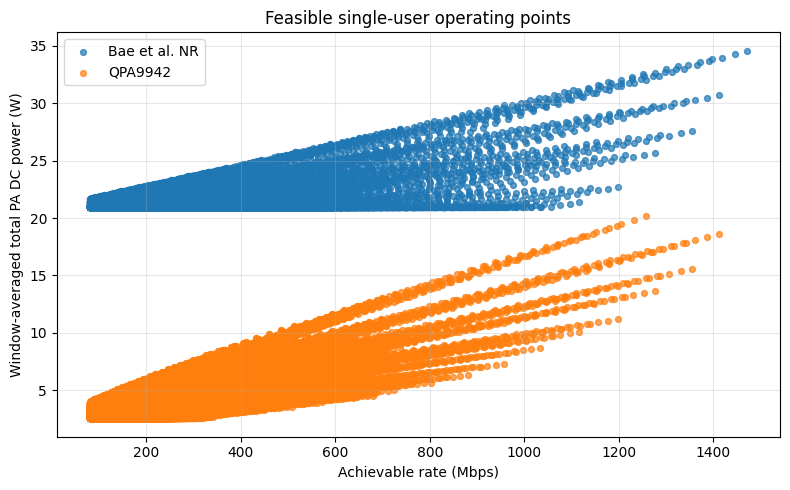

In [6]:
feasible_summary_by_pa = (
    feasible_table.groupby(["pa_id", "pa_name"], dropna=False)
    .agg(
        feasible_rows=("rate_ach_bps", "size"),
        min_rate_bps=("rate_ach_bps", "min"),
        max_rate_bps=("rate_ach_bps", "max"),
        min_power_w=("p_dc_avg_total_w", "min"),
        max_power_w=("p_dc_avg_total_w", "max"),
    )
    .reset_index()
)
display(feasible_summary_by_pa)

fig, ax = plt.subplots(figsize=(8, 5))
for pa_id, df_pa in feasible_table.groupby("pa_id", sort=True):
    ax.scatter(
        df_pa["rate_ach_bps"] / 1e6,
        df_pa["p_dc_avg_total_w"],
        s=18,
        alpha=0.7,
        label=df_pa["pa_name"].iloc[0],
    )
ax.set_xlabel("Achievable rate (Mbps)")
ax.set_ylabel("Window-averaged total PA DC power (W)")
ax.set_title("Feasible single-user operating points")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
export_doc_figure(fig, "single_user_resource_allocation_feasible_points.png")
plt.show()


## 6. Resource interpretation of the selected feasible row

Finally, to make the result easier to interpret, I take the best feasible row under the notebook tie-breaking rule and show it as one resource cuboid inside its available time-frequency-layer envelope.

This is not a packet-level schedule. It is a compact visualization of how much of the available BWP, slot window, and spatial-layer budget the selected operating point consumes. I also summarize the same row in a small table so the reviewer can read the PA choice, MCS, layer count, PRB count, slot count, achieved rate, and average PA DC power in one place.


,pa_name,mcs,layers,allocated_prbs,available_prbs,allocated_slots,available_slots,rate_ach_mbps,window_avg_total_pa_dc_w
0,QPA9942,20,4,26,139,20,20,82.924608,2.564688


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\single_user_resource_allocation_candidate.png


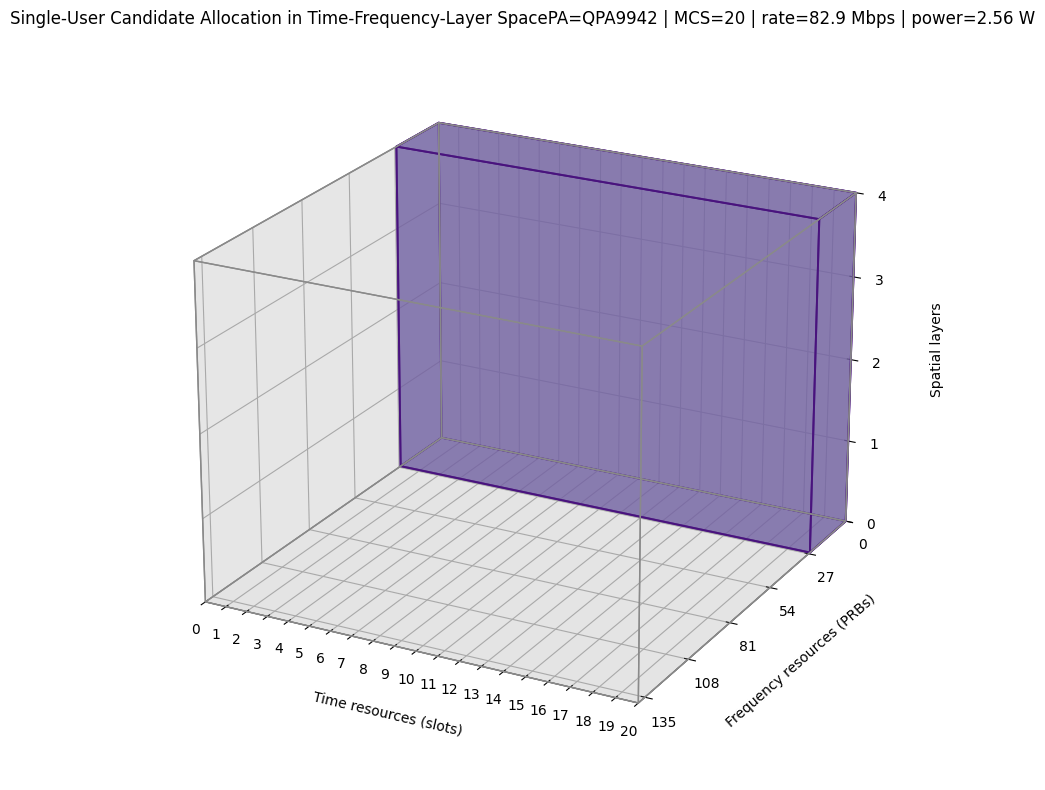

In [7]:
selected_candidate = (
    feasible_table.sort_values(["p_dc_avg_total_w", "bandwidth_hz", "n_prb", "n_slots_on"])
    .reset_index(drop=True)
    .iloc[0]
)

delta_f_hz = float(deployment_summary.loc[0, "delta_f_hz"])
TOTAL_PRBS = int(round(float(selected_candidate["bandwidth_hz"]) / (12.0 * delta_f_hz)))
TOTAL_SLOTS = int(deployment_summary.loc[0, "n_slots_win"])
MAX_LAYERS = int(deployment_summary.loc[0, "n_tx_chains"])

candidate_block = {
    "slot_start": 0,
    "slot_count": int(selected_candidate["n_slots_on"]),
    "prb_count": int(selected_candidate["n_prb"]),
    "layer_count": int(selected_candidate["layers"]),
    "mcs": int(selected_candidate["mcs"]),
    "pa_name": str(selected_candidate["pa_name"]),
    "rate_mbps": float(selected_candidate["rate_ach_bps"]) / 1e6,
    "power_w": float(selected_candidate["p_dc_avg_total_w"]),
}

candidate_summary = pd.DataFrame(
    [
        {
            "pa_name": candidate_block["pa_name"],
            "mcs": candidate_block["mcs"],
            "layers": candidate_block["layer_count"],
            "allocated_prbs": candidate_block["prb_count"],
            "available_prbs": TOTAL_PRBS,
            "allocated_slots": candidate_block["slot_count"],
            "available_slots": TOTAL_SLOTS,
            "rate_ach_mbps": candidate_block["rate_mbps"],
            "window_avg_total_pa_dc_w": candidate_block["power_w"],
        }
    ]
)
display(candidate_summary)


def cuboid(ax, x, y, z, dx, dy, dz, color, alpha=0.45, edgecolor="black", linewidth=1.2):
    v = np.array([
        [x, y, z],
        [x + dx, y, z],
        [x + dx, y + dy, z],
        [x, y + dy, z],
        [x, y, z + dz],
        [x + dx, y, z + dz],
        [x + dx, y + dy, z + dz],
        [x, y + dy, z + dz],
    ])

    faces = [
        [v[i] for i in [0, 1, 2, 3]],
        [v[i] for i in [4, 5, 6, 7]],
        [v[i] for i in [0, 1, 5, 4]],
        [v[i] for i in [2, 3, 7, 6]],
        [v[i] for i in [1, 2, 6, 5]],
        [v[i] for i in [0, 3, 7, 4]],
    ]

    poly = Poly3DCollection(
        faces,
        facecolors=color,
        edgecolor=edgecolor,
        linewidths=linewidth,
        alpha=alpha,
    )
    ax.add_collection3d(poly)


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

envelope_color = colors.to_hex(plt.cm.Greys(0.55))
allocation_color = colors.to_hex(plt.cm.Purples(0.72))

cuboid(
    ax,
    0,
    0,
    0,
    TOTAL_SLOTS,
    TOTAL_PRBS,
    MAX_LAYERS,
    envelope_color,
    alpha=0.08,
    edgecolor="#8a8a8a",
    linewidth=1.0,
)

cuboid(
    ax,
    candidate_block["slot_start"],
    0,
    0,
    candidate_block["slot_count"],
    candidate_block["prb_count"],
    candidate_block["layer_count"],
    allocation_color,
    alpha=0.55,
    edgecolor="#3f007d",
    linewidth=1.4,
)

ax.set_xlabel("Time resources (slots)", labelpad=12)
ax.set_ylabel("Frequency resources (PRBs)", labelpad=14)
ax.zaxis.set_rotate_label(False)
ax.set_zlabel("Spatial layers", rotation=90, labelpad=18)

ax.set_xlim(0, TOTAL_SLOTS)
ax.set_ylim(TOTAL_PRBS, 0)
ax.set_zlim(0, MAX_LAYERS)
ax.set_xticks(np.arange(0, TOTAL_SLOTS + 1, 1))
ax.set_yticks(np.arange(0, TOTAL_PRBS + 1, max(1, TOTAL_PRBS // 5)))
ax.set_zticks(np.arange(0, MAX_LAYERS + 1, 1))
ax.set_title(
    "Single-User Candidate Allocation in Time-Frequency-Layer Space"
    f"PA={candidate_block['pa_name']} | MCS={candidate_block['mcs']} | "
    f"rate={candidate_block['rate_mbps']:.1f} Mbps | power={candidate_block['power_w']:.2f} W"
)
ax.view_init(elev=22, azim=-62)
plt.tight_layout()
export_doc_figure(fig, "single_user_resource_allocation_candidate.png")
plt.show()
